# Laboratorio 5. Naive Bayes

La empresa **SmartStay Advisors** es una firma intermediaria que facilita la búsqueda y selección de
propiedades en Airbnb para clientes corporativos y particulares.
El modelo operativo es el siguiente:

• El cliente proporciona requerimientos específicos (ciudad, presupuesto, tipo de propiedad,
capacidad, duración de estancia).

• SmartStay analiza la oferta disponible y propone propiedades que optimicen precio, calidad
y disponibilidad.

• Airbnb ofrece incentivos económicos a SmartStay cuando logra incrementar el nivel de
ocupación de propiedades con bajo desempeño.
La empresa desea implementar modelos de minería de datos que le permitan:
1. Estimar precios competitivos.
2. Identificar propiedades con baja ocupación.
3. Comprender qué factores influyen en la ocupación y los ingresos.
4. Diseñar estrategias basadas en datos para aumentar la rentabilidad.

## Conjunto de datos a utilizar
listings.RData

In [68]:
import pandas as pd
import pyreadr
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

resultado = pyreadr.read_r('listings.RData')
print("Objetos contenidos en el archivo RData:", resultado.keys())
df = list(resultado.values())[0]
print(df.shape)

numericas = df.select_dtypes(include=['number']).columns.tolist()
print("=== Variables Numéricas ===")
print(numericas)

categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print("=== Variables categoricas ===")
print(categoricas)

limpio = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(limpio, errors='coerce')

Objetos contenidos en el archivo RData: odict_keys(['listings'])
(171748, 80)
=== Variables Numéricas ===
['id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month']
=== Variables categoricas ===
['listing_url', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview'

C:\Users\richi\AppData\Local\Temp\ipykernel_16776\2209224080.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


Usamos el dataset utilizado en laboratorios anteriores, en este se nos da un conjunto de datos con la informaciond de los aribnbs. Los datos obtendios son los siguentes 
| Categorias      | Tipo de Dato   |
| ------------- | ------------     |
| **Numerica**         | 'id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month'     |
| **Categoricas**     | 'listing_url', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'calendar_updated', 'has_availability', 'calendar_last_scraped', 'estimated_revenue_l365d', 'first_review', 'last_review', 'license', 'instant_bookable', 'city'   |

Convertimos el price de una variable categorica a una numerica para poder hacer un analisis mas profundo y que los modelos puedan predecir de una buena manera


In [69]:
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
print("=== CANTIDAD EXACTA DE DATOS VACÍOS ===")
print(faltantes)
print("\n" + "="*40 + "\n")

porcentajes = (faltantes / len(df)) * 100
print("=== PORCENTAJE DE VACÍOS POR COLUMNA ===")
print(porcentajes.round(2).astype(str) + " %")

df = df.dropna(subset=['price'])
df = df.dropna(axis=1, how='all')

numericas = df.select_dtypes(include=['number']).columns.tolist()
if 'price' in numericas: numericas.remove('price')
categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
if 'price' in categoricas: categoricas.remove('price')

imputador_num = SimpleImputer(strategy='median')
imputador_cat = SimpleImputer(strategy='constant', fill_value='Sin Dato')

df[numericas] = imputador_num.fit_transform(df[numericas])
df[categoricas] = imputador_cat.fit_transform(df[categoricas])
print("Borradas las filas sin precio real y columnas basura.")
print("Total de Nulos restantes:", df.isnull().sum().sum())

print(df.shape)

df.head()

=== CANTIDAD EXACTA DE DATOS VACÍOS ===
calendar_updated                171748
price                            95502
estimated_revenue_l365d          95502
neighbourhood_group_cleansed     50683
review_scores_value              40328
review_scores_location           40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores_communication      40308
review_scores_cleanliness        40302
review_scores_rating             40287
reviews_per_month                40287
beds                             31686
bathrooms                        31396
license                          10533
bedrooms                         10473
host_listings_count                876
host_total_listings_count          876
maximum_maximum_nights              71
maximum_minimum_nights              71
minimum_minimum_nights              71
minimum_maximum_nights              71
host_about                           1
dtype: int64


=== PORCENTAJE DE VACÍOS POR COLUMNA ===
calenda

C:\Users\richi\AppData\Local\Temp\ipykernel_16776\2778377555.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
c:\Users\richi\Documents\2026_S1_Local\Mineria\Mineria_Datos\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\richi\Documents\2026_S1_Local\Mineria\Mineria_Datos\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value enco

Borradas las filas sin precio real y columnas basura.
Total de Nulos restantes: 0
(76246, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028.0,...,4.73,4.79,Sin Dato,f,1.0,1.0,0.0,0.0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156.0,...,4.97,4.88,Sin Dato,t,1.0,1.0,0.0,0.0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298.0,...,4.69,4.63,Sin Dato,f,1.0,1.0,0.0,0.0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793.0,...,5.00,4.95,Sin Dato,f,2.0,2.0,0.0,0.0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488.0,...,4.72,4.84,Sin Dato,f,1.0,1.0,0.0,0.0,0.30,"Austin, Texas"


Limpiamos los datos nulos de precio porque no podemos predecir algo que no esta, para los variables numericas aplicamos la solucion de colocar la mediana y para las variables categoricas colocamos el texto de no disponible. 

## Task 1 Creacion del modelo

En esta seccion vamos a implementar el modelo de naiv bayes de regresion, primero vamos a usar todos los datos, usando un onehot encoder para las variables categoricas, usamos GaussianNB para esto:
1. Usaremos todas las variables usando el hiperparametro que nos da el modelo

Mas adelante usaremos un **Var_smoothing** que nos ayudara a ajustar los hiperparametros de mejor manera

In [70]:
Y = df['price'].astype(int) 
X = df.drop(columns=['price'])


categoricas_crudas = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
categoricas = [col for col in categoricas_crudas if X[col].nunique() < 50]
print("Categorías seguras que usará el modelo:", categoricas)

X[categoricas] = X[categoricas].astype(str)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

preprocesador = ColumnTransformer(
    transformers=[
        ('standar-scaler', StandardScaler(), numericas),
        ('one-hot-encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categoricas)
    ])

pipeline = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('regressor', GaussianNB())
])

print("\nEntrenando el modelo...")
pipeline.fit(X_train, Y_train)
predicciones = pipeline.predict(X_test)
rmse = root_mean_squared_error(Y_test, predicciones)
print("\n=== RESULTADOS ===")
print("Modelo Naive Bayes Estándar entrenado con éxito.")
print("Margen de Error (RMSE) promedio en Dólares:", rmse)

C:\Users\richi\AppData\Local\Temp\ipykernel_16776\2700513128.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas_crudas = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


Categorías seguras que usará el modelo: ['last_scraped', 'source', 'host_response_time', 'host_is_superhost', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_group_cleansed', 'room_type', 'bedrooms', 'beds', 'has_availability', 'calendar_last_scraped', 'instant_bookable', 'city']

Entrenando el modelo...

=== RESULTADOS ===
Modelo Naive Bayes Estándar entrenado con éxito.
Margen de Error (RMSE) promedio en Dólares: 3970.2767304320923


Segun el modelo el margen de error RMSE promedio en dolares fue de **3,970.27** lo cual es algo alto, el motivo de esto puede ser por utilizar un valor de var_smoothing por defecto del modelo como se puede ver a continuacion

In [71]:
pipeline.get_params()

{'memory': None,
 'steps': [('preprocesador',
   ColumnTransformer(transformers=[('standar-scaler', StandardScaler(),
                                    ['id', 'scrape_id', 'host_id', 'latitude',
                                     'longitude', 'accommodates', 'bathrooms',
                                     'minimum_nights', 'maximum_nights',
                                     'minimum_nights_avg_ntm',
                                     'maximum_nights_avg_ntm', 'availability_30',
                                     'availability_60', 'availability_90',
                                     'availability_365', 'number_of_reviews',
                                     'number_of_reviews_ltm',
                                     'num...
                                   ('one-hot-encoder',
                                    OneHotEncoder(handle_unknown='ignore',
                                                  sparse_output=False),
                                    ['last_s

Podemos ver que el valor de var_smoothing usado por el modelo es de $1 \times 10^{-9}$ lo cual es un valor por defecto que da el modelo, sin embargo mas adelante vamos a mejorarlo usando cros validation

## Task 2 Analizando los resultados

Con este modelo vamos a analizar los siguientes parametros para ver si el modelo respondio de forma correcta a la predicccion del precio de las casas por noche. 

In [72]:
mae = mean_absolute_error(Y_test, predicciones)
rmse = root_mean_squared_error(Y_test, predicciones)
r2 = r2_score(Y_test, predicciones)

print(f"Error Absoluto Medio (MAE): {mae:.2f} dólares")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} dólares")
print(f"Puntaje R2 (R-Cuadrado): {r2:.4f} ")



Error Absoluto Medio (MAE): 929.58 dólares
Raíz del Error Cuadrático Medio (RMSE): 3970.28 dólares
Puntaje R2 (R-Cuadrado): 0.1324 


Los puntajes de las diferentes pruebas de los errores fueron muy pobres, el valor de $R^{2}$ fue muy bajo, esto nos indica que el modelo solamente es capaz de explicar el 13.2% de los precios reales. El casi 87% restante de las predicciones son prácticamente adivinanzas fuera de toda lógica estadística.

En promedio general, el algoritmo se equivocó por $929 dólares por noche (MAE), lo cual es un margen de error inaceptable para alquileres diarios. Aún más grave es el RMSE ($3,970); como el RMSE castiga fuertemente los errores extremos, este número tan alto revela que el modelo cometió equivocaciones catastróficas en casos específicos (adivinando miles de dólares por encima o por debajo de la realidad).

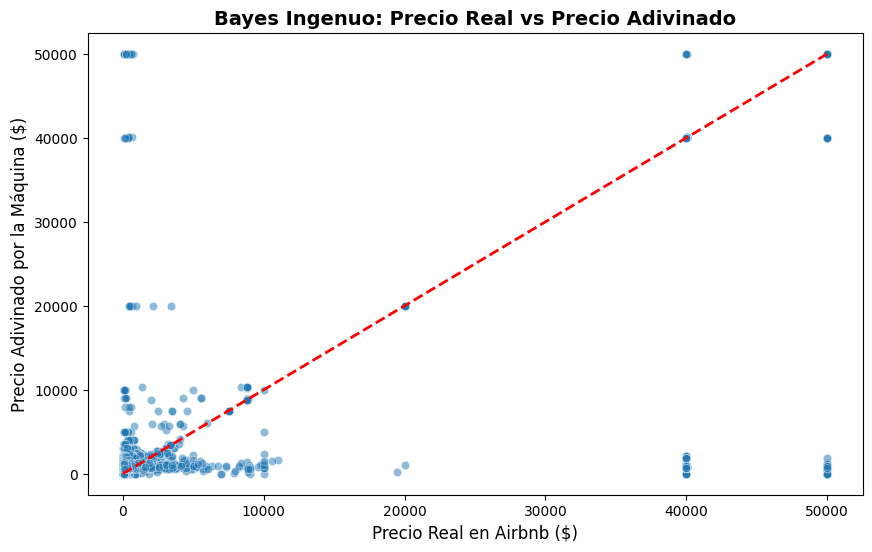

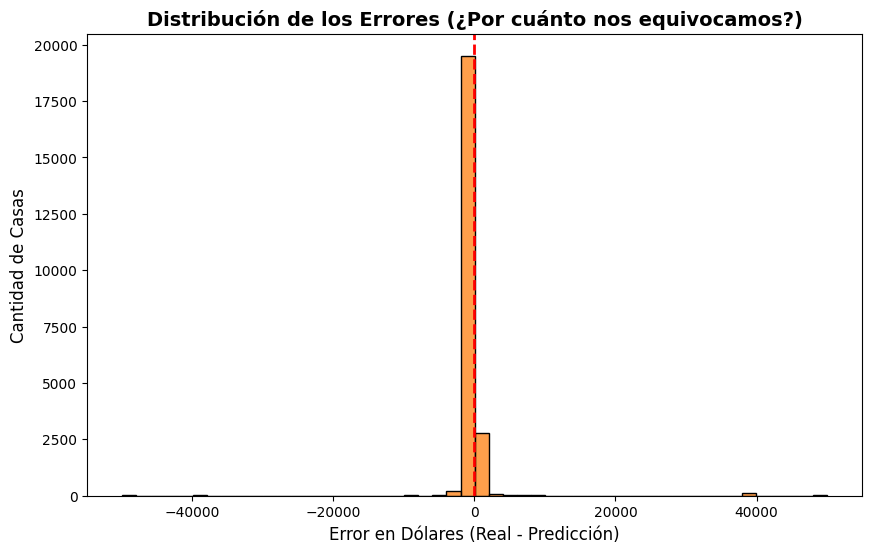

In [73]:
# ======= GRÁFICO 1: REALIDAD VS ADIVINANZA =======
plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y_test, y=predicciones, alpha=0.5, color='#1f77b4')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--', lw=2)
plt.title('Bayes Ingenuo: Precio Real vs Precio Adivinado', fontsize=14, fontweight='bold')
plt.xlabel('Precio Real en Airbnb ($)', fontsize=12)
plt.ylabel('Precio Adivinado por la Máquina ($)', fontsize=12)
plt.show()
# ======= GRÁFICO 2: HISTOGRAMA DE ERRORES (RESIDUOS) =======
residuos = Y_test - predicciones
plt.figure(figsize=(10, 6))
sns.histplot(residuos, bins=50, color='#ff7f0e')
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.title('Distribución de los Errores (¿Por cuánto nos equivocamos?)', fontsize=14, fontweight='bold')
plt.xlabel('Error en Dólares (Real - Predicción)', fontsize=12)
plt.ylabel('Cantidad de Casas', fontsize=12)
plt.show()

Podemos ver que el modelo cometio errores al momento de querer predecir los errores de las casas, esto se puede ver en el grafico de dispersion donde muy pocos puntos se alinean verdaderamente al precio real, ademas de que en la grafica del error hay valor muy atipicos al extremo de la grafica

## Task 3 Comparacion de modelos

**Datos del arbol para la variable respuesta**


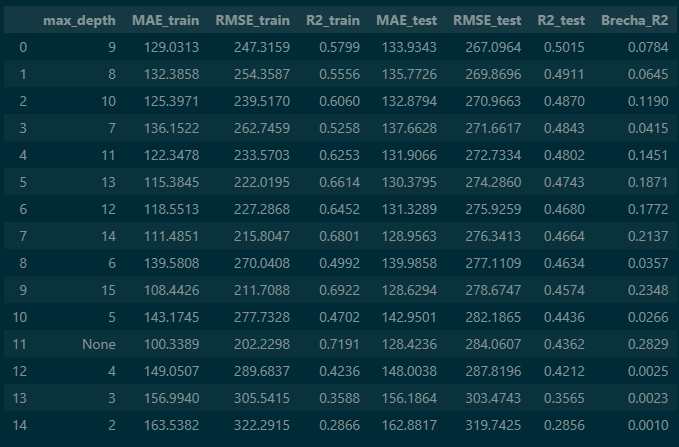


**Datos de la regresion lineal sin ajustes ridge ni lasso**

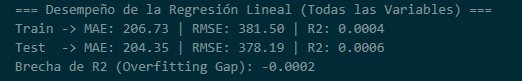

Podemos ver que usando GaussianNb fue el modelo que peor se desempeño de los tres anteriores, esto puede ser debido al uso del var_smoothing que nos dio el modelo, al no tener ese hiperparametro optimo el modelo puede errar
por mucho margen a comparacion de los demas. El unico parametro donde super a la regresion lineal es en el $R^{2}$

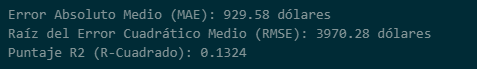